univariate

In [2]:
import pandas as pd
import numpy as numpy 
from sklearn.feature_selection import SelectKBest, chi2


In [3]:
df= pd.read_csv('train.csv')
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [5]:
df.dtypes

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

In [4]:
X = df.iloc[:,0:20]
y = df.iloc[:,-1]

best = SelectKBest(score_func=chi2, k=10)
fit = best.fit(X,y)

df_score = pd.DataFrame(fit.scores_)

df_kolom = pd.DataFrame(X.columns)

feature_score = pd.concat([df_kolom, df_score], axis =1)

feature_score.columns = ['Spesifikasi', 'score']

print(feature_score.nlargest(10,'score'))


      Spesifikasi          score
13            ram  931267.519053
11      px_height   17363.569536
0   battery_power   14129.866576
12       px_width    9810.586750
8       mobile_wt      95.972863
6      int_memory      89.839124
15           sc_w      16.480319
16      talk_time      13.236400
4              fc      10.135166
14           sc_h       9.614878


[0.06085246 0.01937827 0.03450641 0.019671   0.03292732 0.01820787
 0.03570395 0.03373351 0.03676848 0.03389435 0.03410372 0.0474401
 0.04815503 0.38856703 0.03495859 0.03389914 0.03479456 0.01459483
 0.0181259  0.01971748]


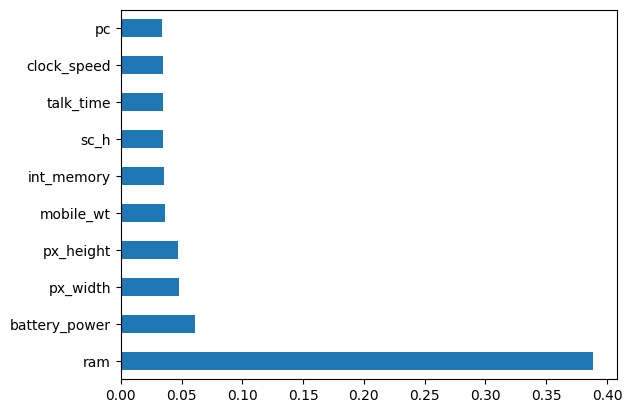

In [11]:
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier


model = ExtraTreesClassifier()

model.fit(X,y)

print(model.feature_importances_)
kolom_terpenting = pd.Series(model.feature_importances_, index=X.columns)
kolom_terpenting.nlargest(10).plot(kind= 'barh')
plt.show()

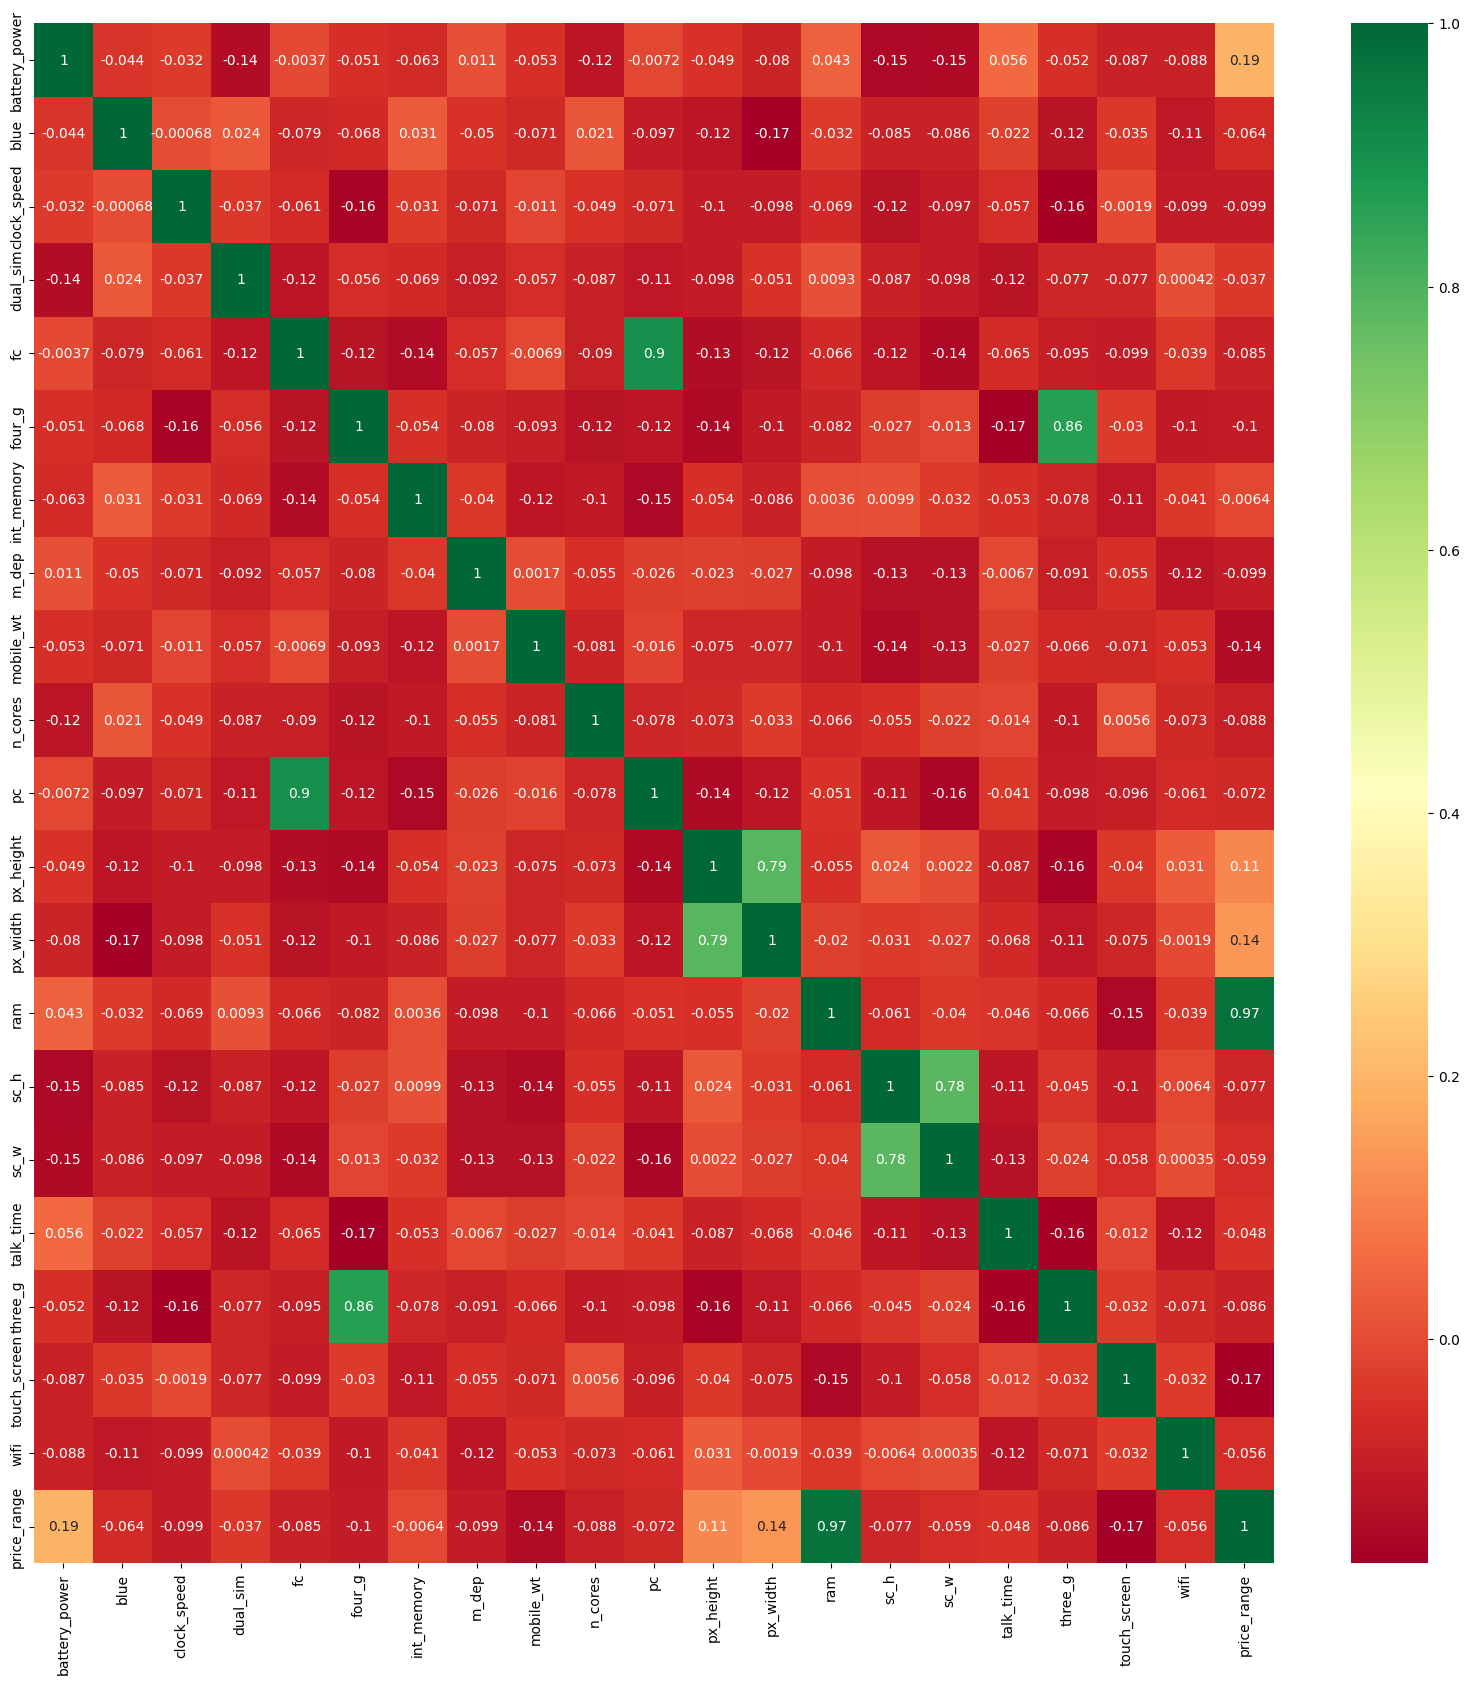

In [20]:
#heatmap 
import seaborn as sns

korelasi = df.corr()

feature_best_coor = korelasi.index
plt.figure(figsize= (20,20))

g = sns.heatmap(korelasi[feature_best_coor].corr(), annot=True, cmap= "RdYlGn")

